In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OPENBLAS_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'
print("IPython: Thread limits set to 4")

IPython: Thread limits set to 4


#### Static Architecture 

Incremental batches: 
- and, not 
- nor 
- nand 
- input 
- output, or 
- xor 


Mechanisms: 
- Naive fine-tuning 
- Rehearsal buffer 
- EWC 
- Synaptic Intelligence (SI) 
- Generative replay 

Applying six search operation for hyperparameter tuning. 
- Grid Search 
- Random Search 
- Bayesian Optimization (surrogate + exploration) 
- Hyperband (successive halving) 
- Population-Based Training (PBT) 
- Evolutionary Algorithm (GA)

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import dgl
import dgl.nn as dglnn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
import random, math, time
from copy import deepcopy
import warnings

warnings.filterwarnings("ignore")

# ---------------------------
# Config / globals
# ---------------------------
CSV_PATH = "../all_circuits_features.csv"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_CFG = {
    "epochs_per_task": 50,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "hidden_dim": 64,
    "test_frac": 0.2,
    "seed": 42,
    "max_edges_per_task": 2000,
    "ewc_lam": 1000.0,
    "si_c": 5.0,
}

random.seed(BASE_CFG["seed"])
np.random.seed(BASE_CFG["seed"])
torch.manual_seed(BASE_CFG["seed"])

# ---------------------------
# Load & preprocess data
# ---------------------------
df = pd.read_csv(CSV_PATH)
df["gate_type"] = df["gate_type"].astype(str).str.strip().str.lower()

label_encoder = LabelEncoder()
df["gate_label"] = label_encoder.fit_transform(df["gate_type"])
classes_found = list(label_encoder.classes_)
class_to_index = {c: i for i, c in enumerate(classes_found)}

feature_columns = [
    "fan_in","fan_out","dist_to_output","is_primary_input","is_primary_output",
    "is_internal","is_key_gate","degree_centrality","betweenness_centrality",
    "closeness_centrality","clustering_coefficient","avg_fan_in_neighbors","avg_fan_out_neighbors"
]
df = df.dropna(subset=feature_columns)
df[feature_columns] = df[feature_columns].astype(float)
scaler = StandardScaler()
df[feature_columns] = scaler.fit_transform(df[feature_columns])

nodes = df["node"].tolist()
node_to_id = {node: i for i, node in enumerate(nodes)}

# Build graph (heuristic)
potential_sources = df[df["fan_out"] > 0]["node"].tolist()
edges = []
for _, row in df.iterrows():
    node_id = node_to_id[row["node"]]
    k = int(row["fan_in"]) if not np.isnan(row["fan_in"]) else 0
    sources = potential_sources[:max(k, 0)]
    for src in sources:
        if src in node_to_id:
            edges.append((node_to_id[src], node_id))

if len(edges) == 0:
    raise ValueError("No edges found from heuristic; check fan_in/fan_out.")

src_nodes, dst_nodes = zip(*edges)
graph = dgl.graph((torch.tensor(src_nodes, dtype=torch.long),
                   torch.tensor(dst_nodes, dtype=torch.long)), num_nodes=len(nodes))
graph = dgl.add_self_loop(graph)
graph.ndata['features'] = torch.tensor(df[feature_columns].values, dtype=torch.float32)
graph.ndata['labels'] = torch.tensor(df["gate_label"].values, dtype=torch.long)
graph = graph.to(device)
graph.ndata['features'] = graph.ndata['features'].to(device)
graph.ndata['labels'] = graph.ndata['labels'].to(device)
full_labels = graph.ndata['labels']

edge_set = set((int(u.item()), int(v.item())) for u, v in zip(*graph.edges()))

# ---------------------------
# Incremental batches
# ---------------------------
incremental_batches = [
    ['and', 'not'],
    ['nor'],
    ['nand'],
    ['input'],
    ['output', 'or'],
    ['xor']
]
batch_label_indices = [[class_to_index[c] for c in batch] for batch in incremental_batches]

def split_for_batch(label_ids, test_frac=0.2, seed=42):
    rng = np.random.RandomState(seed)
    all_nodes = [node_to_id[n] for n, lbl in zip(nodes, df["gate_label"].values) if int(lbl) in label_ids]
    rng.shuffle(all_nodes)
    test_count = max(1, int(len(all_nodes) * test_frac))
    test_nodes = all_nodes[:test_count]
    train_nodes = all_nodes[test_count:]
    if len(train_nodes) == 0 and len(test_nodes) > 0: train_nodes.append(test_nodes.pop())
    if len(test_nodes) == 0 and len(train_nodes) > 0: test_nodes.append(train_nodes.pop())
    return train_nodes, test_nodes, all_nodes

tasks_node_sets = []
for batch_ids in batch_label_indices:
    tr, te, all_subset = split_for_batch(batch_ids, test_frac=BASE_CFG["test_frac"], seed=BASE_CFG["seed"])
    tasks_node_sets.append({"labels": batch_ids, "train_nodes": tr, "test_nodes": te, "all_nodes": all_subset})

in_feats = len(feature_columns)

# ---------------------------
# Static GCN encoder
# ---------------------------
class StaticGCN(nn.Module):
    def __init__(self, in_feats, hidden_dim):
        super().__init__()
        self.conv1 = dglnn.GraphConv(in_feats, hidden_dim, allow_zero_in_degree=True)
        self.conv2 = dglnn.GraphConv(hidden_dim, hidden_dim, allow_zero_in_degree=True)
    def forward(self, g, features):
        h = torch.relu(self.conv1(g, features))
        h = torch.relu(self.conv2(g, h))
        return h

bce_logits_loss = nn.BCEWithLogitsLoss()

def link_raw_scores(node_embeds, edge_index_tensor):
    if edge_index_tensor.shape[0] == 0:
        return torch.empty((0,), device=node_embeds.device)
    u_idx = edge_index_tensor[:, 0]
    v_idx = edge_index_tensor[:, 1]
    return torch.sum(node_embeds[u_idx] * node_embeds[v_idx], dim=1)

def build_class_based_pos_neg(task_idx, max_edges=BASE_CFG["max_edges_per_task"], seed=BASE_CFG["seed"]):
    ts = tasks_node_sets[task_idx]
    nodes_subset = list(set(ts["all_nodes"]))
    batch_label_set = set(ts["labels"])
    pos = []
    for (u, v) in edge_set:
        if (u in nodes_subset) and (v in nodes_subset):
            lu = int(full_labels[u].item()); lv = int(full_labels[v].item())
            if (lu in batch_label_set) and (lv in batch_label_set):
                pos.append((u, v))
    pos = list(set(pos))
    if len(pos) == 0: return None
    if len(pos) > max_edges:
        random.Random(seed).shuffle(pos)
        pos = pos[:max_edges]
    negatives = []
    rng = random.Random(seed)
    target_neg = len(pos)
    attempts = 0
    while len(negatives) < target_neg and attempts < max(100000, 10*target_neg):
        u = rng.choice(nodes_subset); v = rng.choice(nodes_subset)
        if u != v and (u, v) not in edge_set:
            negatives.append((u, v))
        attempts += 1
    if len(negatives) < target_neg:
        candidates = [(u, v) for u in nodes_subset for v in nodes_subset if u != v and (u, v) not in edge_set]
        random.Random(seed+1).shuffle(candidates)
        for p in candidates:
            if p not in negatives:
                negatives.append(p)
            if len(negatives) >= target_neg: break
    pos_arr = np.array(pos, dtype=np.int64)
    neg_arr = np.array(negatives[:target_neg], dtype=np.int64)
    n = len(pos_arr)
    idx = np.arange(n)
    tr_idx, te_idx = train_test_split(idx, test_size=BASE_CFG["test_frac"], random_state=BASE_CFG["seed"])
    pos_tr, pos_te = pos_arr[tr_idx], pos_arr[te_idx]
    neg_tr, neg_te = neg_arr[tr_idx], neg_arr[te_idx]
    train_edges = np.vstack([pos_tr, neg_tr])
    train_labels = np.hstack([np.ones(len(pos_tr)), np.zeros(len(neg_tr))])
    test_edges = np.vstack([pos_te, neg_te])
    test_labels = np.hstack([np.ones(len(pos_te)), np.zeros(len(neg_te))])
    train_edges = torch.tensor(train_edges, dtype=torch.long, device=device)
    train_labels = torch.tensor(train_labels, dtype=torch.float32, device=device)
    test_edges = torch.tensor(test_edges, dtype=torch.long, device=device)
    test_labels = torch.tensor(test_labels, dtype=torch.float32, device=device)
    return train_edges, train_labels, test_edges, test_labels

# ---------------------------
# Mechanisms (Rehearsal, EWC, SI)
# ---------------------------
class RehearsalBufferEdges:
    def __init__(self, size=4000):
        self.size = size
        self.edges = []
        self.labels = []
    def add(self, edges_tensor, labels_tensor):
        e = edges_tensor.detach().cpu().numpy().tolist()
        l = labels_tensor.detach().cpu().numpy().tolist()
        self.edges.extend(e); self.labels.extend(l)
        # deduplicate
        seen = set()
        dedup_e, dedup_l = [], []
        for (u,v), lab in zip(self.edges, self.labels):
            key = (u,v,int(lab))
            if key in seen: continue
            seen.add(key); dedup_e.append([u,v]); dedup_l.append(lab)
        self.edges, self.labels = dedup_e, dedup_l
        if len(self.edges) > self.size:
            idx = np.random.choice(len(self.edges), self.size, replace=False)
            self.edges = [self.edges[i] for i in idx]
            self.labels = [self.labels[i] for i in idx]
    def get(self):
        if len(self.edges) == 0: return None
        edges_t = torch.tensor(self.edges, dtype=torch.long, device=device)
        labels_t = torch.tensor(self.labels, dtype=torch.float32, device=device)
        return edges_t, labels_t

class EWC:
    def __init__(self, model, lam=1000.0):
        self.model = model
        self.lam = lam
        self.star_vars = None
        self.fisher = None
    def compute_fisher_link(self, g, features, train_edges, train_labels, sample_size=2048):
        n = train_edges.shape[0]
        if n == 0: return
        sel = np.random.choice(n, min(sample_size, n), replace=False)
        e_sel = train_edges[sel]; l_sel = train_labels[sel]
        self.model.train()
        emb = self.model(g, features)
        logits = link_raw_scores(emb, e_sel)
        loss = bce_logits_loss(logits, l_sel)
        self.model.zero_grad(); loss.backward()
        self.fisher = [p.grad.detach().cpu().numpy()**2 if p.grad is not None else np.zeros_like(p.detach().cpu().numpy())
                       for p in self.model.parameters()]
        self.star_vars = [p.detach().cpu().numpy().copy() for p in self.model.parameters()]
    def penalty(self, model):
        if self.fisher is None or self.star_vars is None:
            return torch.tensor(0.0, device=device)
        total = 0.0
        for p, p_star, f in zip(model.parameters(), self.star_vars, self.fisher):
            W = p.detach().cpu().numpy()
            shape = tuple(min(a, b) for a, b in zip(W.shape, f.shape))
            slices = tuple(slice(0, s) for s in shape)
            W_s = W[slices]; p_star_s = p_star[slices]; f_s = f[slices]
            total += np.sum(f_s * (W_s - p_star_s)**2)
        return torch.tensor((self.lam/2.0)*total, dtype=torch.float32, device=device)

class SITracker:
    def __init__(self, model, c=5.0, eps=1e-3):
        self.model = model
        self.c = c
        self.eps = eps
        self.prev_vars = [p.detach().cpu().numpy().copy() for p in model.parameters()]
        self.w_importance = [np.zeros_like(p.detach().cpu().numpy()) for p in model.parameters()]
        self.path_int = [np.zeros_like(p.detach().cpu().numpy()) for p in model.parameters()]
    def update(self, grads):
        for i,(g,p) in enumerate(zip(grads,self.model.parameters())):
            if g is not None:
                delta = p.detach().cpu().numpy() - self.prev_vars[i]
                self.path_int[i] += (-g.detach().cpu().numpy()) * delta
            self.prev_vars[i] = p.detach().cpu().numpy().copy()
    def consolidate(self):
        for i,p in enumerate(self.model.parameters()):
            delta = p.detach().cpu().numpy() - self.prev_vars[i]
            self.w_importance[i] += self.path_int[i]/(delta**2+self.eps)
            self.path_int[i] = np.zeros_like(p.detach().cpu().numpy())
    def penalty(self, model):
        total=0.0
        for i,p in enumerate(model.parameters()):
            W = p.detach().cpu().numpy()
            prev = self.prev_vars[i]
            imp = self.w_importance[i]
            shape = tuple(min(a, b) for a, b in zip(W.shape, prev.shape))
            slices = tuple(slice(0, s) for s in shape)
            W_s = W[slices]; prev_s = prev[slices]; imp_s = imp[slices]
            total += np.sum(imp_s*(W_s - prev_s)**2)
        return torch.tensor(self.c*total, dtype=torch.float32, device=device)

# ---------------------------
# Train/eval per task; cumulative reporting
# ---------------------------
MECHANISMS = ["naive", "rehearsal", "ewc", "si", "gen_replay"]

def train_tasks_linkpred_static_gcn(mechanism, cfg):
    model = StaticGCN(in_feats, cfg["hidden_dim"]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])

    # Mechanism setup
    if mechanism == "naive":
        buffer = None; ewc = None; si = None
    elif mechanism in ["rehearsal", "gen_replay"]:
        buffer = RehearsalBufferEdges(size=cfg.get("max_edges_per_task", BASE_CFG["max_edges_per_task"]))
        ewc = None; si = None
    elif mechanism == "ewc":
        buffer = None; ewc = EWC(model, lam=cfg.get("ewc_lam", BASE_CFG["ewc_lam"])); si = None
    elif mechanism == "si":
        buffer = None; ewc = None; si = SITracker(model, c=cfg.get("si_c", BASE_CFG["si_c"]))
    else:
        raise ValueError(f"Unknown mechanism {mechanism}")

    results = {"per_task": [], "arch_summaries": []}

    for t_idx in range(len(incremental_batches)):
        print(f"\n=== Training Task {t_idx}: {incremental_batches[t_idx]} ===")
        data = build_class_based_pos_neg(t_idx, max_edges=cfg.get("max_edges_per_task", BASE_CFG["max_edges_per_task"]),
                                         seed=cfg.get("seed", BASE_CFG["seed"]))
        if data is None:
            print("  No positive edges found for this task  skipping.")
            results["per_task"].append({
                "task_index": t_idx,
                "task_classes": incremental_batches[t_idx],
                "metrics": {f"task_{i}_acc": float('nan') for i in range(t_idx+1)},
                "train_edges": 0,
                "params_trained": sum(p.numel() for p in model.parameters()),
                "params_detail": {"encoder": sum(p.numel() for p in model.parameters()), "head": 0}
            })
            results["arch_summaries"].append(f"StaticGCN: GraphConv({in_feats}->{cfg['hidden_dim']}) x2 (emb {cfg['hidden_dim']})")
            continue

        train_edges, train_labels, test_edges, test_labels = data
        n_train = len(train_edges)
        print(f"  Train pairs: {n_train}, Test pairs: {len(test_edges)}")

        total_epochs = cfg["epochs_per_task"]
        for epoch in range(1, total_epochs + 1):
            model.train()
            optimizer.zero_grad()
            node_emb = model(graph, graph.ndata['features'])
            logits = link_raw_scores(node_emb, train_edges)
            tloss = bce_logits_loss(logits, train_labels)

            reg_loss = torch.tensor(0.0, device=device)
            if ewc: reg_loss = reg_loss + ewc.penalty(model)
            if si: reg_loss = reg_loss + si.penalty(model)
            total_loss = tloss + reg_loss

            grads = torch.autograd.grad(total_loss, model.parameters(), retain_graph=True, allow_unused=True)
            if si: si.update(grads)

            total_loss.backward()
            optimizer.step()

        if si: si.consolidate()
        if ewc: ewc.compute_fisher_link(graph, graph.ndata['features'], train_edges, train_labels)
        if mechanism in ["rehearsal", "gen_replay"] and buffer is not None:
            buffer.add(train_edges, train_labels)

        # Evaluate on all seen tasks (0..t_idx)
        task_metrics = {}
        for eval_idx in range(t_idx + 1):
            data_eval = build_class_based_pos_neg(eval_idx, max_edges=cfg.get("max_edges_per_task", BASE_CFG["max_edges_per_task"]),
                                                  seed=cfg.get("seed", BASE_CFG["seed"]))
            if data_eval is None:
                acc = float('nan'); cm = np.array([[]]); cr = ""
            else:
                te_edges_eval, te_labels_eval = data_eval[2], data_eval[3]
                node_emb_eval = model(graph, graph.ndata['features'])
                scores = link_raw_scores(node_emb_eval, te_edges_eval)
                probs = torch.sigmoid(scores).detach().cpu().numpy()
                preds_bin = (probs > 0.5).astype(int)
                y_true = te_labels_eval.detach().cpu().numpy().astype(int)
                acc = (preds_bin == y_true).mean()
                cm = confusion_matrix(y_true, preds_bin, labels=[0,1])
                cr = classification_report(y_true, preds_bin, labels=[0,1],
                                           target_names=["no-edge","edge"], zero_division=0)
            task_metrics[f"task_{eval_idx}_acc"] = acc
            task_metrics[f"task_{eval_idx}_cm"] = cm
            task_metrics[f"task_{eval_idx}_cr"] = cr

        arch_summary = f"StaticGCN: GraphConv({in_feats}->{cfg['hidden_dim']}) | GraphConv({cfg['hidden_dim']}->{cfg['hidden_dim']}); dot-product scorer"
        enc_params = sum(p.numel() for p in model.parameters())
        results["per_task"].append({
            "task_index": t_idx,
            "task_classes": incremental_batches[t_idx],
            "metrics": task_metrics,
            "train_edges": int(n_train),
            "params_trained": enc_params,
            "params_detail": {"encoder": enc_params, "head": 0}
        })
        results["arch_summaries"].append(arch_summary)

    return results

def score_results(res):
    # same metric as before: mean of seen-task accuracies in last recorded per_task entry
    last = res["per_task"][-1]["metrics"]
    accs = []
    for k, v in last.items():
        if k.endswith("_acc") and isinstance(v, float) and not math.isnan(v):
            accs.append(v)
    return float(np.mean(accs)) if accs else 0.0

# ---------------------------
# Search methods (restored)
# ---------------------------
def run_with_cfg(mechanism, cfg):
    mech = mechanism if mechanism != "gen_replay" else "rehearsal"
    return train_tasks_linkpred_static_gcn(mech, cfg)

def grid_search(mechanism):
    grid = []
    for lr in [5e-4, 1e-3]:
        for wd in [0.0, 1e-5]:
            for hidden in [32, 64, 128]:
                grid.append({
                    "lr": lr, "weight_decay": wd, "hidden_dim": hidden,
                    "epochs_per_task": BASE_CFG["epochs_per_task"],
                    "test_frac": BASE_CFG["test_frac"], "seed": BASE_CFG["seed"],
                    "max_edges_per_task": BASE_CFG["max_edges_per_task"],
                    "ewc_lam": BASE_CFG["ewc_lam"], "si_c": BASE_CFG["si_c"]
                })
    best_res, best_cfg, best_score = None, None, -1
    total = len(grid)
    print(f"  Grid: total {total} configs")
    for i, cfg in enumerate(grid, 1):
        print(f"    Grid config {i}/{total}: lr={cfg['lr']}, wd={cfg['weight_decay']}, hidden={cfg['hidden_dim']}")
        res = run_with_cfg(mechanism, cfg)
        sc = score_results(res)
        print(f"      Score: {sc:.4f}")
        if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
    return best_res, best_cfg

def random_search(mechanism, trials=12):
    best_res, best_cfg, best_score = None, None, -1
    print(f"  Random search: trials={trials}")
    for t in range(1, trials+1):
        cfg = deepcopy(BASE_CFG)
        cfg["lr"] = 10**np.random.uniform(-4, -2.5)
        cfg["weight_decay"] = 10**np.random.uniform(-6, -3)
        cfg["hidden_dim"] = random.choice([32, 64, 128, 256])
        cfg["ewc_lam"] = random.choice([500.0, 1000.0, 2000.0])
        cfg["si_c"] = random.choice([2.0, 5.0, 10.0])
        print(f"    Trial {t}/{trials}: lr={cfg['lr']:.3e}, wd={cfg['weight_decay']:.3e}, hidden={cfg['hidden_dim']}")
        res = run_with_cfg(mechanism, cfg)
        sc = score_results(res)
        print(f"      Score: {sc:.4f}")
        if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
    return best_res, best_cfg

def bayesian_search(mechanism, init_points=3, iters=5):
    # lightweight bayes for runtime; tune init_points/iters as needed
    X, y = [], []
    def sample_cfg():
        return {
            "lr": 10**np.random.uniform(-4, -2.5),
            "weight_decay": 10**np.random.uniform(-6, -3),
            "hidden_dim": random.choice([32,64,128,256]),
            "epochs_per_task": BASE_CFG["epochs_per_task"],
            "test_frac": BASE_CFG["test_frac"], "seed": BASE_CFG["seed"],
            "max_edges_per_task": BASE_CFG["max_edges_per_task"],
            "ewc_lam": random.choice([500.0,1000.0,2000.0]),
            "si_c": random.choice([2.0,5.0,10.0]),
        }
    def cfg_to_vec(cfg):
        return [math.log10(cfg["lr"]), math.log10(cfg["weight_decay"]+1e-30), float(cfg["hidden_dim"])]
    best_res, best_cfg, best_score = None, None, -1
    print(f"  Bayesian search: init={init_points}, iters={iters}")
    for _ in range(init_points):
        cfg = sample_cfg(); res = run_with_cfg(mechanism, cfg); sc = score_results(res)
        X.append(cfg_to_vec(cfg)); y.append(sc)
        if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
        print(f"    Init sample score {sc:.4f}")
    try:
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
        kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-3)
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
        for it in range(iters):
            gp.fit(np.array(X), np.array(y))
            cands = [sample_cfg() for _ in range(24)]
            X_c = np.array([cfg_to_vec(c) for c in cands])
            mu, sigma = gp.predict(X_c, return_std=True)
            best_y = max(y)
            Z = (mu - best_y) / (sigma + 1e-8)
            from scipy.stats import norm
            EI = (mu - best_y) * norm.cdf(Z) + sigma * norm.pdf(Z)
            idx = int(np.argmax(EI))
            cfg = cands[idx]; res = run_with_cfg(mechanism, cfg); sc = score_results(res)
            X.append(cfg_to_vec(cfg)); y.append(sc)
            if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
            print(f"    Bayes iter {it+1}/{iters} score {sc:.4f}")
    except Exception as e:
        print("  Bayesian search skipped due to missing GP tools:", e)
    return best_res, best_cfg

def hyperband_search(mechanism, R=30, eta=3):
    brackets = []
    s_max = int(math.floor(math.log(R, eta)))
    for s in range(s_max, -1, -1):
        n = int(math.ceil((s_max+1) * eta**s / (s+1)))
        r = int(R * eta**(-s))
        brackets.append((n, int(r)))
    best_res, best_cfg, best_score = None, None, -1
    print(f"  Hyperband: R={R}, eta={eta}, brackets={len(brackets)}")
    for n, r in brackets:
        print(f"    Bracket n={n}, r={r}")
        configs = []
        for _ in range(n):
            cfg = deepcopy(BASE_CFG)
            cfg["lr"] = 10**np.random.uniform(-4,-2.5)
            cfg["weight_decay"] = 10**np.random.uniform(-6,-3)
            cfg["hidden_dim"] = random.choice([32,64,128])
            cfg["epochs_per_task"] = int(r)
            cfg["ewc_lam"] = random.choice([500.0,1000.0,2000.0])
            cfg["si_c"] = random.choice([2.0,5.0,10.0])
            configs.append(cfg)
        results = []
        for i,cfg in enumerate(configs,1):
            print(f"      Eval config {i}/{len(configs)} (r={r})")
            res = run_with_cfg(mechanism, cfg); sc = score_results(res)
            results.append((sc, res, cfg))
            print(f"        Score {sc:.4f}")
        k = max(1, int(len(results)/eta))
        results.sort(key=lambda x: x[0], reverse=True)
        configs = [deepcopy(r[2]) for r in results[:k]]
        for i,cfg in enumerate(configs,1):
            cfg["epochs_per_task"] = min(R, cfg["epochs_per_task"] * eta)
            res = run_with_cfg(mechanism, cfg); sc = score_results(res)
            if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
            print(f"      Promote {i}/{len(configs)} new score {sc:.4f}")
    return best_res, best_cfg

def pbt_search(mechanism, population_size=6, generations=2, init_epochs=10):
    population = []
    for _ in range(population_size):
        cfg = deepcopy(BASE_CFG)
        cfg["lr"] = 10**np.random.uniform(-4,-2.5)
        cfg["weight_decay"] = 10**np.random.uniform(-6,-3)
        cfg["hidden_dim"] = random.choice([32,64,128])
        cfg["ewc_lam"] = random.choice([500.0,1000.0,2000.0])
        cfg["si_c"] = random.choice([2.0,5.0,10.0])
        cfg["epochs_per_task"] = init_epochs
        population.append(cfg)
    best_res, best_cfg, best_score = None, None, -1
    print(f"  PBT: pop={population_size}, gens={generations}, init_epochs={init_epochs}")
    for g in range(generations):
        print(f"    Generation {g+1}/{generations}")
        scored = []
        for i,cfg in enumerate(population,1):
            print(f"      Eval pop {i}/{len(population)}")
            res = run_with_cfg(mechanism, cfg); sc = score_results(res)
            scored.append((sc, res, cfg))
            if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
            print(f"        Score {sc:.4f}")
        scored.sort(key=lambda x: x[0], reverse=True)
        top = scored[:population_size//2]
        population = [deepcopy(x[2]) for x in top] + [deepcopy(x[2]) for x in top]
        for i in range(len(population)//2, len(population)):
            population[i]["lr"] *= random.choice([0.7, 1.3])
            population[i]["hidden_dim"] = random.choice([32,64,128])
        if g == generations - 1:
            for cfg in population:
                cfg["epochs_per_task"] = BASE_CFG["epochs_per_task"]
    final_res = run_with_cfg(mechanism, best_cfg) if best_cfg is not None else (None, None)
    return final_res, best_cfg

def evolutionary_search(mechanism, population_size=8, generations=3):
    def random_cfg():
        cfg = deepcopy(BASE_CFG)
        cfg["lr"] = 10**np.random.uniform(-4,-2.5)
        cfg["weight_decay"] = 10**np.random.uniform(-6,-3)
        cfg["hidden_dim"] = random.choice([32,64,128,256])
        cfg["ewc_lam"] = random.choice([500.0,1000.0,2000.0])
        cfg["si_c"] = random.choice([2.0,5.0,10.0])
        return cfg
    def mutate(cfg):
        c = deepcopy(cfg)
        c["lr"] *= 10**np.random.uniform(-0.1,0.1)
        c["weight_decay"] *= 10**np.random.uniform(-0.2,0.2)
        c["hidden_dim"] = random.choice([32,64,128,256])
        return c
    population = [random_cfg() for _ in range(population_size)]
    best_res, best_cfg, best_score = None, None, -1
    print(f"  GA: pop={population_size}, gens={generations}")
    for g in range(generations):
        print(f"    Generation {g+1}/{generations}")
        scored = []
        for i,cfg in enumerate(population,1):
            print(f"      Eval {i}/{len(population)}")
            res = run_with_cfg(mechanism, cfg); sc = score_results(res)
            scored.append((sc, res, cfg))
            if sc > best_score: best_score, best_res, best_cfg = sc, res, cfg
            print(f"        Score {sc:.4f}")
        scored.sort(key=lambda x: x[0], reverse=True)
        elites = [deepcopy(x[2]) for x in scored[:population_size//3]]
        new_pop = elites + [mutate(random.choice(elites)) for _ in range(population_size - len(elites))]
        population = new_pop
    final_res = run_with_cfg(mechanism, best_cfg) if best_cfg is not None else (None, None)
    return final_res, best_cfg

# ---------------------------
# Run all searches and capture bests + detailed printing
# ---------------------------
search_methods = [
    ("Grid", grid_search),
    ("Random", random_search),
    ("Bayesian", bayesian_search),
    ("Hyperband", hyperband_search),
    ("Population-based (PBT)", pbt_search),
    ("Evolutionary (GA)", evolutionary_search),
]

all_results = []
start = time.time()
for mech_name, runner in search_methods:
    print(f"\n\n=== Running Search Method: {mech_name} ===")
    for mechanism in MECHANISMS:
        print(f"\n-- Search {mech_name} | Mechanism: {mechanism} --")
        best_res, best_cfg = runner(mechanism)
        if best_res is None:
            print("  No best result found for this search/mechanism (possible skipped).")
            continue
        best_score = score_results(best_res)
        all_results.append({"search": mech_name, "mechanism": mechanism, "cfg": best_cfg, "res": best_res, "best_score": best_score})

        # Detailed printing for the best config for this search/mechanism
        print(f"\n=== Best (Search: {mech_name} | Mechanism: {mechanism}) ===")
        print(f"Config: LR={best_cfg['lr']:.3e}  WD={best_cfg['weight_decay']:.3e}  Hidden={best_cfg['hidden_dim']}")
        print(f"Best score (avg seen-task acc on final step): {best_score:.4f}")

        # Print per-task metrics and also show prior-task accs after each task (CIL forgetting view)
        for pt in best_res["per_task"]:
            t_idx = pt["task_index"]
            print(f"\nTask {t_idx} classes: {pt['task_classes']}")
            # print acc entries
            for k, v in pt["metrics"].items():
                if k.endswith("_acc"):
                    if isinstance(v, float) and not math.isnan(v):
                        print(f"  {k}: {v*100:.2f}%")
                    else:
                        print(f"  {k}: NaN")
            # print confusion matrices and classification reports (for all eval'd prior tasks)
            for eval_idx in range(t_idx+1):
                cm = pt["metrics"].get(f"task_{eval_idx}_cm")
                cr = pt["metrics"].get(f"task_{eval_idx}_cr")
                if cm is not None and hasattr(cm, 'size') and cm.size:
                    print(f"  Confusion Matrix (evaluated task {eval_idx} after training task {t_idx}):\n{cm}")
                if cr is not None and len(cr) > 0:
                    print(f"  Classification Report (evaluated task {eval_idx} after training task {t_idx}):\n{cr}")
            print(f"  Architecture: {best_res['arch_summaries'][t_idx] if best_res['arch_summaries'] else 'N/A'}")
            print(f"  Training edges used: {pt.get('train_edges', 0)}")
            print(f"  Trainable params (encoder): {pt['params_detail']['encoder']}")

elapsed = time.time() - start
print(f"\nAll searches completed in {elapsed/60:.1f} minutes. Total best trials recorded: {len(all_results)}")

# ---------------------------
# Comparative summary table + save
# ---------------------------
rows = []
for entry in all_results:
    res = entry["res"]
    cfg = entry["cfg"]
    last = res["per_task"][-1]
    final_accs = []
    for k,v in last["metrics"].items():
        if k.endswith("_acc") and isinstance(v, float) and not math.isnan(v):
            final_accs.append(v)
    rows.append({
        "Search": entry["search"],
        "Mechanism": entry["mechanism"],
        "LR": f"{cfg['lr']:.3e}",
        "WD": f"{cfg['weight_decay']:.3e}",
        "HiddenDim": cfg["hidden_dim"],
        "Avg final acc": f"{(np.mean(final_accs)*100):.2f}%" if len(final_accs)>0 else "NaN",
        "Task0 acc": f"{(last['metrics'].get('task_0_acc', float('nan'))*100):.2f}%",
        "Task1 acc": f"{(last['metrics'].get('task_1_acc', float('nan'))*100):.2f}%",
        "Task2 acc": f"{(last['metrics'].get('task_2_acc', float('nan'))*100):.2f}%",
        "Task3 acc": f"{(last['metrics'].get('task_3_acc', float('nan'))*100):.2f}%",
        "Task4 acc": f"{(last['metrics'].get('task_4_acc', float('nan'))*100):.2f}%",
        "Task5 acc": f"{(last['metrics'].get('task_5_acc', float('nan'))*100):.2f}%",
        "Last arch": res["arch_summaries"][-1] if res["arch_summaries"] else "",
        "Edges (last task train)": last.get("train_edges", 0),
        "Params trained (last task)": last["params_trained"]
    })

summary_df = pd.DataFrame(rows)
print("\n\n=== Final Comparative Summary Table ===")
print(summary_df.to_string(index=False))
summary_df.to_csv("summary_static_gcn_results.csv", index=False)
print("\nSaved summary_static_gcn_results.csv")




=== Running Search Method: Grid ===

-- Search Grid | Mechanism: naive --
  Grid: total 12 configs
    Grid config 1/12: lr=0.0005, wd=0.0, hidden=32

=== Training Task 0: ['and', 'not'] ===
  Train pairs: 3200, Test pairs: 800

=== Training Task 1: ['nor'] ===
  Train pairs: 3200, Test pairs: 800

=== Training Task 2: ['nand'] ===
  Train pairs: 3200, Test pairs: 800

=== Training Task 3: ['input'] ===
  Train pairs: 2902, Test pairs: 726

=== Training Task 4: ['output', 'or'] ===
  Train pairs: 2818, Test pairs: 706

=== Training Task 5: ['xor'] ===
  Train pairs: 180, Test pairs: 46
      Score: 0.6049
    Grid config 2/12: lr=0.0005, wd=0.0, hidden=64

=== Training Task 0: ['and', 'not'] ===
  Train pairs: 3200, Test pairs: 800

=== Training Task 1: ['nor'] ===
  Train pairs: 3200, Test pairs: 800

=== Training Task 2: ['nand'] ===
  Train pairs: 3200, Test pairs: 800

=== Training Task 3: ['input'] ===
  Train pairs: 2902, Test pairs: 726

=== Training Task 4: ['output', 'or'] =

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("\n=== All Hyperparameter Trials (summary) for 20 records. Check CSV file for full records.===")
display(summary_df.head(20))  # show first 20 rows



=== All Hyperparameter Trials (summary) for 20 records. Check CSV file for full records.===


,Search,Mechanism,LR,WD,HiddenDim,Avg final acc,Task0 acc,Task1 acc,Task2 acc,Task3 acc,Task4 acc,Task5 acc,Last arch,Edges (last task train),Params trained (last task)
0,Grid,naive,1.000e-03,1.000e-05,32,65.22%,71.12%,56.88%,52.62%,70.39%,68.56%,71.74%,StaticGCN: GraphConv(13->32) | GraphConv(32->3...,180,1504
1,Grid,rehearsal,1.000e-03,0.000e+00,128,69.10%,65.75%,62.38%,56.50%,73.42%,73.94%,82.61%,StaticGCN: GraphConv(13->128) | GraphConv(128-...,180,18304
2,Grid,ewc,1.000e-03,0.000e+00,128,68.15%,72.50%,62.75%,53.25%,62.67%,72.95%,84.78%,StaticGCN: GraphConv(13->128) | GraphConv(128-...,180,18304
3,Grid,si,1.000e-03,0.000e+00,128,66.38%,70.00%,62.00%,58.63%,53.31%,76.06%,78.26%,StaticGCN: GraphConv(13->128) | GraphConv(128-...,180,18304
4,Grid,gen_replay,1.000e-03,0.000e+00,128,65.91%,64.12%,62.88%,55.62%,57.30%,72.95%,82.61%,StaticGCN: GraphConv(13->128) | GraphConv(128-...,180,18304
5,Random,naive,2.593e-03,1.011e-06,32,67.89%,77.50%,57.00%,53.37%,64.46%,76.77%,78.26%,StaticGCN: GraphConv(13->32) | GraphConv(32->3...,180,1504
6,Random,rehearsal,2.962e-03,5.962e-06,256,70.88%,77.75%,70.12%,74.00%,73.00%,76.06%,54.35%,StaticGCN: GraphConv(13->256) | GraphConv(256-...,180,69376
7,Random,ewc,7.404e-04,9.735e-06,256,63.88%,68.38%,65.25%,56.38%,54.41%,73.65%,65.22%,StaticGCN: GraphConv(13->256) | GraphConv(256-...,180,69376
8,Random,si,1.518e-03,3.300e-06,256,69.31%,72.50%,64.75%,59.62%,55.65%,80.74%,82.61%,StaticGCN: GraphConv(13->256) | GraphConv(256-...,180,69376
9,Random,gen_replay,2.227e-03,1.871e-06,64,69.87%,81.00%,63.88%,56.12%,55.10%,84.84%,78.26%,StaticGCN: GraphConv(13->64) | GraphConv(64->6...,180,5056


Saved gcn_static_hpo_HiddenDim_max_per_tick.pdf


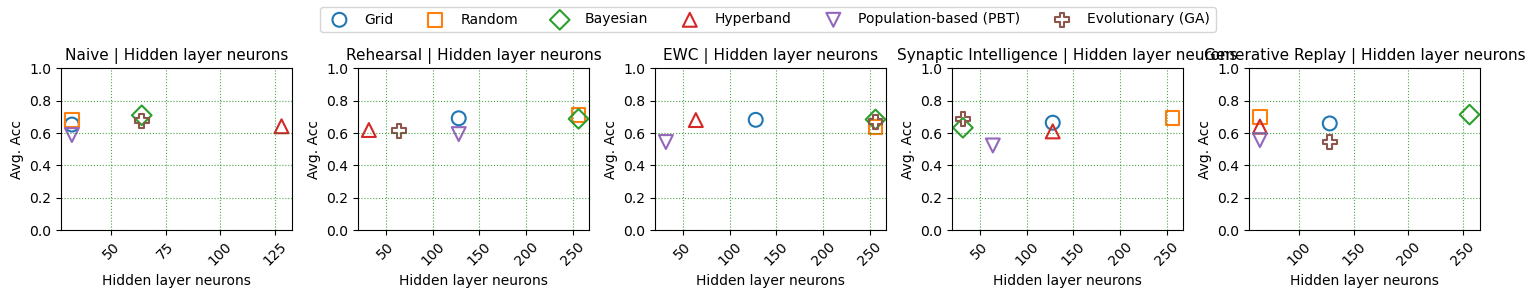

Saved gcn_static_hpo_LR_max_per_tick.pdf


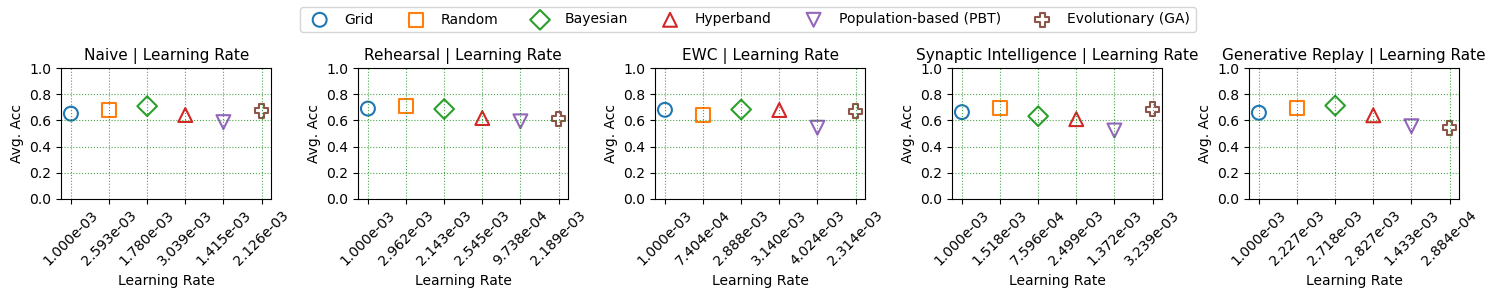

Saved gcn_static_hpo_WD_max_per_tick.pdf


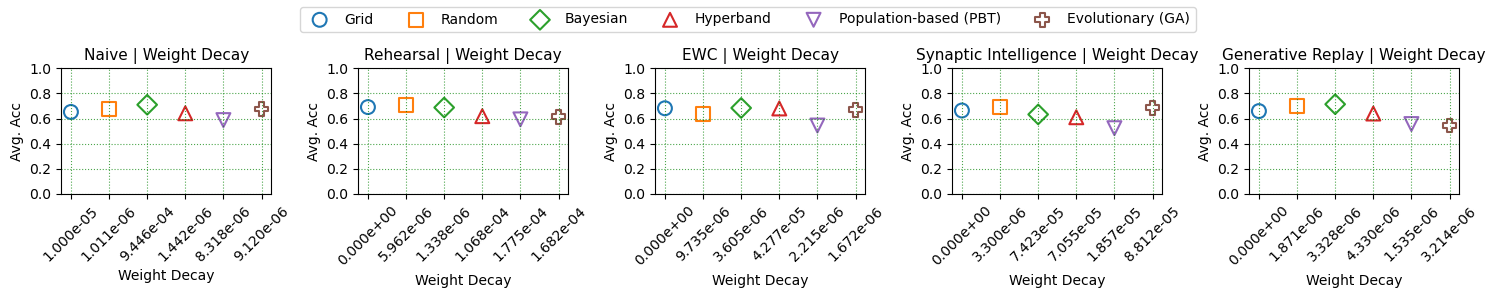

Saved gcn_static_hpo_Heads_max_per_tick.pdf


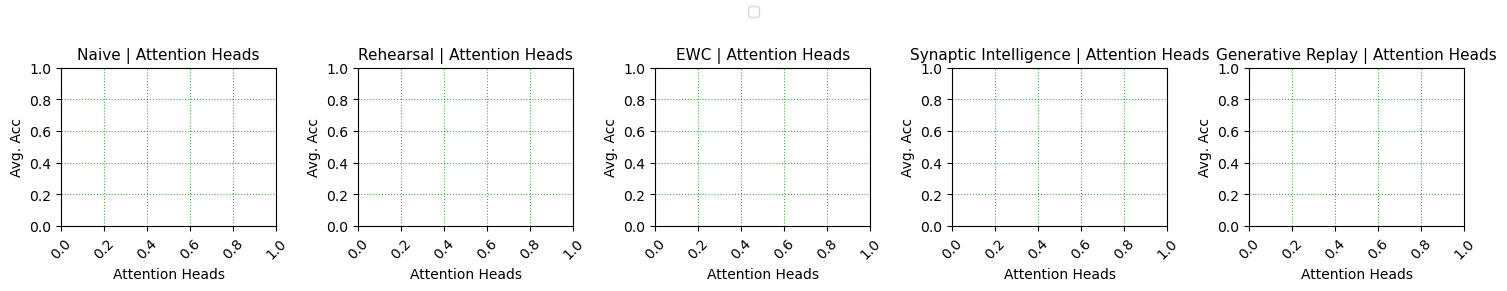

Saved gcn_static_hpo_Dropout_max_per_tick.pdf


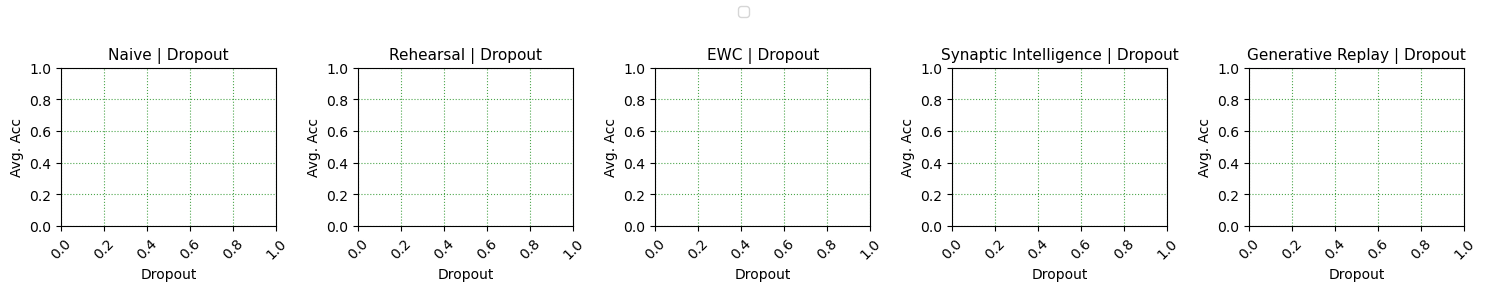

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import numpy as np

# Methods, colors, and markers
methods = summary_df["Search"].unique()
palette = sns.color_palette("tab10", n_colors=len(methods))
method_colors = dict(zip(methods, palette))
marker_styles = ["o", "s", "D", "^", "v", "P", "X", "*"]
method_markers = dict(zip(methods, marker_styles))

def pretty_param_label(param):
    if param == "HiddenDim": return "Hidden layer neurons"
    if param == "LR": return "Learning Rate"
    if param == "WD": return "Weight Decay"
    if param == "ewc_lam": return "EWC ?"
    if param == "si_c": return "SI c"
    if param == "Dropout": return "Dropout"
    if param == "Heads": return "Attention Heads"
    return param

# Mechanism pretty names
mech_map = {
    "naive": "Naive",
    "rehearsal": "Rehearsal",
    "ewc": "EWC",
    "si": "Synaptic Intelligence",
    "gen_replay": "Generative Replay"
}

# Hyperparameters to plot (matching summary_df columns)
hyperparams = ["HiddenDim", "LR", "WD", "Heads", "Dropout"]

for param in hyperparams:
    fig, axes = plt.subplots(1, len(MECHANISMS), figsize=(3*len(MECHANISMS), 3), squeeze=False)

    if param in summary_df.columns:
        tested_vals = sorted(summary_df[param].dropna().unique())
    else:
        tested_vals = []

    for j, mech in enumerate(MECHANISMS):
        ax = axes[0, j]
        df_mech = summary_df[summary_df["Mechanism"] == mech]

        if param in df_mech.columns and len(tested_vals) > 0:
            for method in methods:
                df_m = df_mech[df_mech["Search"] == method]
                for xval in tested_vals:
                    df_x = df_m[df_m[param] == xval]
                    if len(df_x) == 0:
                        continue
                    # Convert "Avg final acc" string to float
                    df_x["AvgAccFloat"] = df_x["Avg final acc"].str.rstrip("%").astype(float)/100.0
                    best_row = df_x.loc[df_x["AvgAccFloat"].idxmax()]
                    ax.scatter(
                        [best_row[param]], [best_row["AvgAccFloat"]],
                        label=method,
                        marker=method_markers[method],
                        facecolors='none',
                        edgecolors=method_colors[method],
                        s=100, linewidths=1.5
                    )

        # Axis styling
        param_label = pretty_param_label(param)
        ax.set_title(f"{mech_map.get(mech, mech)} | {param_label}", fontsize=11)
        ax.set_xlabel(param_label)
        ax.set_ylabel("Avg. Acc")
        ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        '''
        if param in ["LR", "WD"]:
            ax.set_xticks(tested_vals)
            ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x}"))
        else:
            ax.set_xticks(tested_vals)
        '''
        ax.tick_params(axis='x', rotation=45)
        ax.grid(True, linestyle=':', color='green', alpha=0.7)

    handles, labels = axes[0, -1].get_legend_handles_labels()
    uniq = {}
    for h, l in zip(handles, labels):
        if l not in uniq:
            uniq[l] = h
    fig.legend(list(uniq.values()), list(uniq.keys()), loc="upper center", ncol=len(methods))

    plt.tight_layout(rect=[0,0,1,0.9])
    filename = f"gcn_static_hpo_{param}_max_per_tick.pdf"
    plt.savefig(filename, format="pdf")
    print(f"Saved {filename}")
    plt.show()


In [11]:
import pprint

# Mechanisms of interest
mechanisms = ["naive", "rehearsal", "ewc", "si", "gen_replay"]

# Pretty printer
pp = pprint.PrettyPrinter(indent=2)

# Explicit batch accuracy columns (static summary uses TaskX acc)
batch_acc_cols = [f"Task{i} acc" for i in range(6)]

# Hyperparameter columns (matching summary_df)
hyperparam_cols = ["HiddenDim", "LR", "WD", "Heads", "Dropout", "ewc_lam", "si_c"]

for mech in mechanisms:
    df_mech = summary_df[summary_df["Mechanism"] == mech]
    if df_mech.empty:
        print(f"\n=== No data for {mech} ===")
        continue
    
    # Convert Avg final acc to numeric for comparison
    df_mech["AvgAccFloat"] = df_mech["Avg final acc"].str.rstrip("%").astype(float)
    best_row = df_mech.loc[df_mech["AvgAccFloat"].idxmax()]
    
    # Collect batch accuracies
    batch_accs = {col: best_row[col] for col in batch_acc_cols if col in best_row}
    
    # Collect hyperparameters
    hyperparams = {col: best_row[col] for col in hyperparam_cols if col in best_row}
    
    # Build dictionary
    best_config = {
        "Mechanism": mech.capitalize(),
        "Search Method": best_row["Search"],
        "Avg Accuracy": best_row["Avg final acc"],
        "Batch Accuracies": batch_accs,
        "Hyperparameters": hyperparams
    }
    
    print(f"\n=== Best configuration for {mech.upper()} ===")
    pp.pprint(best_config)



=== Best configuration for NAIVE ===
{ 'Avg Accuracy': '70.96%',
  'Batch Accuracies': { 'Task0 acc': '72.62%',
                        'Task1 acc': '63.62%',
                        'Task2 acc': '62.62%',
                        'Task3 acc': '73.28%',
                        'Task4 acc': '75.35%',
                        'Task5 acc': '78.26%'},
  'Hyperparameters': { 'HiddenDim': np.int64(64),
                       'LR': '1.780e-03',
                       'WD': '9.446e-04'},
  'Mechanism': 'Naive',
  'Search Method': 'Bayesian'}

=== Best configuration for REHEARSAL ===
{ 'Avg Accuracy': '70.88%',
  'Batch Accuracies': { 'Task0 acc': '77.75%',
                        'Task1 acc': '70.12%',
                        'Task2 acc': '74.00%',
                        'Task3 acc': '73.00%',
                        'Task4 acc': '76.06%',
                        'Task5 acc': '54.35%'},
  'Hyperparameters': { 'HiddenDim': np.int64(256),
                       'LR': '2.962e-03',
               

Saved gcn_static_hpo_max_acc.pdf


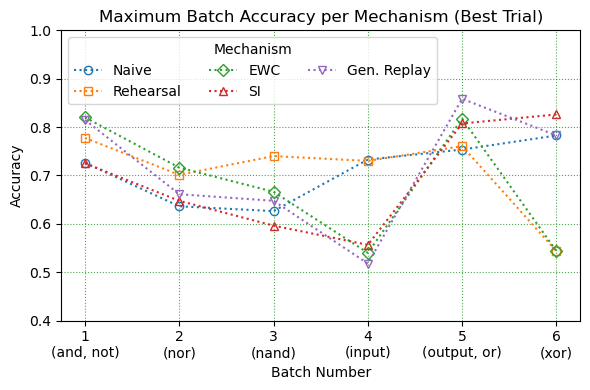

In [13]:
import matplotlib.pyplot as plt

# Use the mechanisms list from the experiment code
mechanisms = MECHANISMS

# Batch accuracy columns as created in summary_df
batch_acc_cols = [f"Task{i} acc" for i in range(6)]

# Class labels introduced in each batch
batch_labels = [
    ["and", "not"],   # Batch 1
    ["nor"],          # Batch 2
    ["nand"],         # Batch 3
    ["input"],        # Batch 4
    ["output", "or"], # Batch 5
    ["xor"]           # Batch 6
]

# Color palette
colors = plt.get_cmap("tab10")

# Assign distinct markers per mechanism
mech_markers = {
    "naive": "o",        # circle
    "rehearsal": "s",    # square
    "ewc": "D",          # diamond
    "si": "^",           # triangle up
    "gen_replay": "v"    # triangle down
}

# Mechanism display names for legend
mech_map = {
    "naive": "Naive",
    "rehearsal": "Rehearsal",
    "ewc": "EWC",
    "si": "SI",
    "gen_replay": "Gen. Replay"
}

plt.figure(figsize=(6, 4))

for i, mech in enumerate(mechanisms):
    df_mech = summary_df[summary_df["Mechanism"] == mech]
    if df_mech.empty:
        continue
    
    # Convert Avg final acc to numeric for comparison
    df_mech["AvgAccFloat"] = df_mech["Avg final acc"].str.rstrip("%").astype(float)/100.0
    best_row = df_mech.loc[df_mech["AvgAccFloat"].idxmax()]
    
    # Collect batch accuracies
    batch_accs = []
    for col in batch_acc_cols:
        if col in best_row:
            val = best_row[col]
            # Convert string like "85.23%" to float if needed
            if isinstance(val, str) and val.endswith("%"):
                val = float(val.rstrip("%"))/100.0
            batch_accs.append(val)
    
    # Plot line with hollow markers and dotted style
    plt.plot(
        range(1, len(batch_accs)+1), batch_accs,
        label=mech_map.get(mech, mech),
        linestyle=":",
        marker=mech_markers[mech],
        color=colors(i),
        markerfacecolor="none",
        markeredgecolor=colors(i),
        linewidth=1.5
    )

plt.xlabel("Batch Number")
plt.ylabel("Accuracy")
plt.title("Maximum Batch Accuracy per Mechanism (Best Trial)")

# Set xticks and custom labels (batch number + class label)
plt.xticks(
    ticks=range(1, len(batch_acc_cols)+1),
    labels=[f"{i}\n({', '.join(lbl)})" for i, lbl in enumerate(batch_labels, start=1)]
)
plt.yticks([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.legend(title="Mechanism", ncol=3, loc = 'upper left')
plt.grid(True, linestyle=":", color="green", alpha=0.7)

plt.tight_layout()
filename = "gcn_static_hpo_max_acc.pdf"
plt.savefig(filename, format="pdf")
print(f"Saved {filename}")
plt.show()
